# TC Track Diagnostics - Tracking Method Comparison

Focused notebook for comparing TempestExtremes tracking outputs across different tracking method sets (set1-set5).


In [1]:
import os
import sys
import subprocess
import re
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from global_land_mask import globe
from pathlib import Path

from esp_lab.utils import mov_utils as mov
from esp_lab import env_paths
from esp_lab.utils.dask_util import DaskConfig, get_cluster_client
from esp_lab.utils.notebook_resources import restart_notebook_cluster, close_notebook_resources

# Python interpreter for the tracking script.
# When the kernel IS e3sm_analysis, sys.executable is already correct.
PYTHON = sys.executable
print(f"PYTHON      : {PYTHON}")
print(f"CONDA_PREFIX: {os.environ.get('CONDA_PREFIX', '(not set — fallback paths used)')}")

# PROJ data path — auto-resolved when running under the e3sm_analysis kernel
# (CONDA_PREFIX is set).  Hardcoded fallback only needed if kernel is not activated.
# This MUST be set before importing Cartopy/GDAL/PyProj or any package that
# transitively imports them; otherwise the environment variables may be
# applied too late to influence which native PROJ data actually gets loaded.
_proj_path = os.path.join(os.environ.get("CONDA_PREFIX", ""), "share", "proj")
if not os.path.exists(_proj_path):
    _proj_path = "/global/homes/z/zhan391/.conda/envs/e3sm_analysis/share/proj"
os.environ["PROJ_LIB"]  = _proj_path
os.environ["PROJ_DATA"] = _proj_path

_repo_override = os.environ.get("ESP_LAB_REPO_ROOT")
_repo_candidates = ([Path(_repo_override).expanduser().resolve()] if _repo_override
                    else [Path.cwd().resolve(), *Path.cwd().resolve().parents])
REPO_ROOT = next((p for p in _repo_candidates
                  if (p / "scripts" / "run_process_tc_track_e3sm.py").is_file()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Start Jupyter inside ESP-Lab or set ESP_LAB_REPO_ROOT to its checkout.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Local helper modules used by this diagnostics notebook.
WORKFLOWS_DIR = REPO_ROOT / "workflows"
if str(WORKFLOWS_DIR) not in sys.path:
    sys.path.append(str(WORKFLOWS_DIR))
from workflows.tropical_cyclones.track_density import (
    read_stitch_nodes_tracks, read_stitch_nodes_tracks_parallel,
)

PYTHON      : /global/homes/z/zhan391/.conda/envs/e3sm_analysis/bin/python
CONDA_PREFIX: /global/homes/z/zhan391/.conda/envs/e3sm_analysis


## Configuration — fill in ALL fields before running

Fields left as `None` will cause the **Validate** cell to raise an error.

In [2]:
# ------------------------------------------------------------------ #
#  CASES
# ------------------------------------------------------------------ #
E3SM_HINDCASTS = {
    "JRA55_FOSIRL": {
        "sim_dir": "/global/cfs/cdirs/e3smdata/simulations/S2S2D",
        "stream_tag": "eam.h2",
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL",
        "label": "E3SMv3-FOSIRL",
        "year_end": 2018,
    },
    "Reanalysis": {
        "sim_dir": "/global/cfs/cdirs/e3sm/S2S2D/simulation",
        "stream_tag": "eam.h3",
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce",
        "label": "E3SMv3-Reanalysis",
        "year_end": 2018,
    },
    "4DEnVarOcn": {
        "sim_dir": "/global/cfs/cdirs/e3sm/S2S2D/simulation",
        "stream_tag": "eam.h3",
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn",
        "label": "E3SMv3-4DEnVarOcn",
        "year_end": 2011,
    },
}

# select one case in above to process diagnostics 
case = "JRA55_FOSIRL"
case_prefix = E3SM_HINDCASTS[case]["case_prefix"]
hist_tag = E3SM_HINDCASTS[case]["stream_tag"]
label = E3SM_HINDCASTS[case]["label"]
year_end = E3SM_HINDCASTS[case]["year_end"]

years  = 1980
yeare  = 2018 if year_end is None else int(year_end)
yexcl  = None          # set to a year int to exclude, or None

init_months = [5, 11]  # May and November starts

lead_years = [y for y in np.arange(years, yeare + 1) if y != yexcl]

CASES = [
    f"{case_prefix}_{year}{init_month:02d}0100"
    for init_month in init_months
    for year in lead_years
]

print(f"Total cases: {len(CASES)}")
print("First few:", CASES[:3])
print("Last few: ", CASES[-3:])

# ------------------------------------------------------------------ #
#  ENSEMBLE / PARSET
# ------------------------------------------------------------------ #

case_nens = 10
members   = [f"EN{i:02d}" for i in range(case_nens)]
MEMBERS   = members
NENS      = None   # e.g. 3 for a quick test
PARSET    = "set3"

# Replace existing diagnostics NetCDF files when rerunning with a new method/setup.
OVERWRITE_OUTPUT = True

# ------------------------------------------------------------------ #
#  PATHS
# ------------------------------------------------------------------ #
S2D_DIAG_ROOT = env_paths.s2d_diag_root()
E3SMLE_DIAG_DIR = S2D_DIAG_ROOT
OBS_DIAG_DIR = S2D_DIAG_ROOT / "observations"
CESM_SMYLE_DIAG_DIR = S2D_DIAG_ROOT / "CESM-SMYLE"
NMME_DIAG_DIR = S2D_DIAG_ROOT / "NMME"
MODES_VARIABILITY_DIAG_DIR = S2D_DIAG_ROOT

# -----------------------------------------------------------------------------
# Directory setup
# -----------------------------------------------------------------------------
# Override the root for a different workspace with ESP_LAB_S2D_DIAG_ROOT.
DIAG_ROOT = S2D_DIAG_ROOT
E3SMLE_OUTDIR = E3SMLE_DIAG_DIR
CESM_SMYLE_OUTDIR = CESM_SMYLE_DIAG_DIR
SMYLE_BENCHMARK_DIR = str(CESM_SMYLE_OUTDIR)
NMME_OUTDIR = NMME_DIAG_DIR
MODES_OUTDIR = MODES_VARIABILITY_DIAG_DIR


# TempestExtremes products, ensured below from raw history files when missing.
TRACK_DIR    = env_paths.raw_model_root()

# Diagnostics written by this notebook.
OUTDIR       = E3SMLE_OUTDIR / case / "tc_track"

# Local helper modules used by this diagnostics notebook.
WORKFLOWS_DIR  = REPO_ROOT / "workflows"

# Default figure output directory for this HPC environment.
FIGURE_OUTDIR = env_paths.figure_root()
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

TABLE_OUTDIR = Path(S2D_DIAG_ROOT / "multimodel" / "tropical_cyclones" / "tables")
TABLE_OUTDIR.mkdir(parents=True, exist_ok=True)

# Mapping of parameter sets to descriptive professional names
PSET_DISPLAY_NAMES = {
    "set1": "Z200-Z500 (Height Anomaly)",
    "set2": "T200-T500 (Temp Anomaly)",
    "set3": "Z300-Z500 (Height Anomaly)",
    "set4": "T300-T500 (Temp Anomaly)",
    "set5": "T400 (Upper-level Temp)",
}

SIMULATION_DIR = Path(E3SM_HINDCASTS[case]["sim_dir"])
HISTORY_STREAM = E3SM_HINDCASTS[case]["stream_tag"]
TC_PARSETS = ["set1", "set2", "set3", "set4", "set5"]

# Input policy: auto builds missing/stale tracks, require validates only,
# rebuild regenerates the requested tracking products.
TC_INPUT_MODE = "auto"
DASK_SETTINGS = {
    "enabled": True,
    "cluster_type": os.environ.get("CLUSTER_TYPE", "local"),
    "workers": 4,
    "cores": 1,
    "memory_limit": "4GB",
}
TC_TRACK_SETTINGS = {
    "sim_dir": SIMULATION_DIR,
    "stream_tag": HISTORY_STREAM,
    "phis_stream_tag": "eam.h0",
    "grid": "ne30pg2",
    "connect_file": "/global/cfs/cdirs/e3sm/zhan391/TempestExtremes/grid_info/outCS_ne30pg2_connect.txt",
    "te_bin": os.environ.get("ESP_LAB_TE_BIN", str(Path(sys.executable).parent)),
    "nco_bin": os.environ.get("ESP_LAB_NCO_BIN", str(Path(sys.executable).parent)),
    "workers": 10,
    "psl_fo_mag": 200.0, "psl_fo_dist": 8.0,
    "wc_fo_dist": 8.0, "wc_max_offset": 3.0, "merge_dist": 6.0,
    "traj_range": 10.0, "traj_min_length": "10", "traj_max_gap": "3",
    "max_topo": 150.0, "max_lat": 50.0, "min_wind": 8.0, "sci_dist": 9,
    "warm_core_overrides": {},  # Default set1–set5 fields/thresholds match 0_run_tc_track_diag.
}


Total cases: 78
First few: ['WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1981050100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1982050100']
Last few:  ['WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_2016110100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_2017110100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_2018110100']


## Ensure and validate tracking inputs

This calls the TC processor directly; running `preprocessing/tc/0_run_tc_track_diag.ipynb` first is optional.
Raw simulation history and TempestExtremes/NCO are required only when products need building.

`TC_INPUT_MODE="auto"` reuses complete track/histogram pairs and builds missing products.
`"require"` validates without processing; `"rebuild"` reruns tracking. New products record their tracking settings; complete legacy products are reused with a provenance notice.
IBTrACS remains an external observational input. Diagnostic calculations and figures run after input preparation.


In [3]:
import subprocess, xarray as xr, matplotlib.pyplot as plt, cartopy.crs as ccrs

# ---- enforce all required fields are set ----
_required = {
    "CASES":        CASES,
    "TRACK_DIR":  TRACK_DIR,
    "OUTDIR":     OUTDIR,
    "WORKFLOWS_DIR":  WORKFLOWS_DIR,
    "MEMBERS":      MEMBERS,
    "PARSET":       PARSET,
    "OVERWRITE_OUTPUT": OVERWRITE_OUTPUT,
}
_missing = [k for k, v in _required.items() if v is None]
if _missing:
    raise ValueError(
        "The following required fields are still None — fill them in the Configuration cell:\n"
        + "\n".join(f"  {k}" for k in _missing)
    )

# Resolve members from explicit configuration, cached products, or raw history.
if not CASES:
    raise ValueError("No cases selected")
_ref_case_dir = TRACK_DIR / CASES[0]
_raw_case_dir = SIMULATION_DIR / CASES[0]
_member_root = _ref_case_dir if _ref_case_dir.is_dir() else _raw_case_dir
members_avail = list(MEMBERS) if MEMBERS else sorted(
    p.name for p in _member_root.glob("EN*") if p.is_dir()
)
if NENS is not None:
    if NENS < 1:
        raise ValueError("NENS must be positive")
    members_avail = members_avail[:NENS]
if not members_avail:
    raise ValueError("No members selected; set MEMBERS or check SIMULATION_DIR")

from workflows.tropical_cyclones.inputs import ensure_tracks
TC_INPUT_REPORT = ensure_tracks(
    repo_root=REPO_ROOT, track_root=TRACK_DIR, cases=CASES,
    members=members_avail, parsets=TC_PARSETS,
    settings=TC_TRACK_SETTINGS, mode=TC_INPUT_MODE,
)
print("TC input report:", TC_INPUT_REPORT)

OUTDIR.mkdir(parents=True, exist_ok=True)

print("Configuration valid ✓")
print(f"  Cases         : {len(CASES)} total  ({CASES[0]}  ...  {CASES[-1]})")
print(f"  TRACK_DIR    : {TRACK_DIR}")
print(f"  OUTDIR       : {OUTDIR}")
print(f"  WORKFLOWS_DIR   : {WORKFLOWS_DIR}")
print(f"  Members       : {members_avail}  (NENS={NENS})")
print(f"  Parset        : {PARSET}")
print(f"  Overwrite out : {OVERWRITE_OUTPUT}")
print(f"\n  Example input: {TRACK_DIR / CASES[0] / members_avail[0] / 'post' / 'atm' / 'tc-analysis'}")


[TC inputs] Reused 3900 legacy pairs without settings receipts; use rebuild to enforce the configured tracking thresholds.
TC input report: {'reused': 0, 'legacy_reused': 3900, 'built': 0}
Configuration valid ✓
  Cases         : 78 total  (WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100  ...  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_2018110100)
  TRACK_DIR    : /global/cfs/cdirs/e3sm/S2S2D/post_process
  OUTDIR       : /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/tc_track
  WORKFLOWS_DIR   : /global/u2/z/zhan391/code/ESP-Lab/workflows
  Members       : ['EN00', 'EN01', 'EN02', 'EN03', 'EN04', 'EN05', 'EN06', 'EN07', 'EN08', 'EN09']  (NENS=None)
  Parset        : set3
  Overwrite out : True

  Example input: /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis


## Available track outputs

The preceding cell ensures track and histogram pairs for all five method sets.


In [4]:
# List all track files produced across all configured cases/members
track_files = []
_missing_track_pairs = []
for case in CASES:
    for member in members_avail:
        analysis_dir = TRACK_DIR / case / member / "post" / "atm" / "tc-analysis"
        f = analysis_dir / f"{case}_{member}_{PARSET}_TCS_track.txt"
        if f.is_file():
            track_files.append(f)
        else:
            _missing_track_pairs.append((case, member))

_expected_track_files = len(CASES) * len(members_avail)
print(
    f"Track files found: {len(track_files)} of {_expected_track_files} expected  "
    f"({len(CASES)} cases x {len(members_avail)} members)"
)
if _missing_track_pairs:
    preview = ", ".join(f"{c}/{m}" for c, m in _missing_track_pairs[:5])
    more = "" if len(_missing_track_pairs) <= 5 else f" ... ({len(_missing_track_pairs) - 5} more)"
    print(f"Missing: {preview}{more}")

for f in track_files[:20]:
    size_kb = f.stat().st_size / 1e3
    print(f"  {f.relative_to(TRACK_DIR)}  ({size_kb:.0f} kB)")
if len(track_files) > 20:
    print(f"  ... ({len(track_files) - 20} more)")

# Summarise one track file (StitchNodes format)
if track_files:
    fpath = track_files[0]
    print(f"Inspecting: {fpath}")
    with open(fpath) as fh:
        raw = fh.readlines()
    n_storms = sum(1 for line in raw if line.strip().startswith("start"))
    n_points = sum(1 for line in raw if line.strip() and not line.strip().startswith(("start", "#")))
    print(f"  Storm tracks : {n_storms}")
    print(f"  Track points : {n_points}")
    if n_storms > 0:
        print(f"  Avg length   : {n_points / n_storms:.1f} steps/storm")
    print("\nFirst 20 lines:")
    for line in raw[:20]:
        print(" ", line.rstrip())
else:
    print("No track files found — run the input ensure cell first.")


Track files found: 780 of 780 expected  (78 cases x 10 members)
  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set3_TCS_track.txt  (145 kB)
  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN01/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN01_set3_TCS_track.txt  (130 kB)
  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN02/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN02_set3_TCS_track.txt  (161 kB)
  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN03/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN03_set3_TCS_track.txt  (134 kB)
  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN04/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN04_set3_TCS_track.txt  (137 kB)
  WCYCL20TR_ne30

In [5]:
from cartopy.util import add_cyclic_point
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd


def figure_filename(*parts, ext="png"):
    """Build consistent, readable lowercase snake_case figure filenames."""
    import re

    clean_parts = ["fig"]
    for part in parts:
        if part is None:
            continue
        text = str(part).strip()
        if not text:
            continue
        text = re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()
        if text:
            clean_parts.append(text)

    suffix = ext.lstrip(".").lower()
    return "_".join(clean_parts) + f".{suffix}"


def _setup_map_axis(
    ax,
    title,
    extent=None,
    show_bottom_labels=False,
    show_left_labels=True,
    title_fontsize=10.5,
    tick_fontsize=8.5,
):
    if extent is None:
        extent = globals().get("QUICK_SANITY_EXTENT", [0, 360, -70, 70])
    coastline_kw = globals().get(
        "QUICK_SANITY_COASTLINE_KW", dict(linewidth=0.6, color="0.25", zorder=3)
    )
    border_kw = globals().get(
        "QUICK_SANITY_BORDER_KW", dict(linewidth=0.3, edgecolor="0.5", alpha=0.5, zorder=3)
    )
    gridline_kw = globals().get(
        "QUICK_SANITY_GRIDLINE_KW",
        dict(linewidth=0.3, color="0.75", alpha=0.5, linestyle="--", zorder=3),
    )

    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN, facecolor="#f8fafc", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#e2e8f0", zorder=0)
    ax.coastlines(**coastline_kw)
    ax.add_feature(cfeature.BORDERS, **border_kw)
    ax.set_title(title, fontsize=title_fontsize, fontweight="bold", pad=6, loc="left")

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, **gridline_kw)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = show_bottom_labels
    gl.left_labels = show_left_labels
    gl.xlabel_style = {"size": tick_fontsize, "color": ".3"}
    gl.ylabel_style = {"size": tick_fontsize, "color": ".3"}
    return gl


def _plot_tracks(ax, tracks, track_kw=None, genesis_kw=None):
    if tracks.empty:
        ax.text(
            0.5,
            0.5,
            "no tracks",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=globals().get("QUICK_SANITY_ANNOTATION_FONTSIZE", 11),
            color="0.4",
        )
        return 0, 0

    if track_kw is None:
        track_kw = globals().get(
            "QUICK_SANITY_TRACK_KW",
            dict(colors="#0f172a", linewidths=0.65, alpha=0.65),
        )
    if genesis_kw is None:
        genesis_kw = globals().get(
            "QUICK_SANITY_GENESIS_KW",
            dict(s=13, marker="o", color="#2563eb", edgecolor="white", linewidth=0.4, alpha=0.9),
        )

    segments = []
    starts = []
    group_cols = [c for c in ["case", "member", "storm_id"] if c in tracks.columns]
    if not group_cols:
        group_cols = ["storm_id"] if "storm_id" in tracks.columns else tracks.columns[:1]

    for _, storm in tracks.sort_values("time").groupby(group_cols):
        points = storm[["lon", "lat"]].to_numpy()
        if len(points) < 2:
            continue
        starts.append(points[0])
        split_at = np.where(np.abs(np.diff(points[:, 0])) > 180.0)[0] + 1
        for segment in np.split(points, split_at):
            if len(segment) >= 2:
                segments.append(segment)

    if segments:
        track_lines = LineCollection(
            segments,
            transform=ccrs.PlateCarree(),
            zorder=4,
            **track_kw,
        )
        ax.add_collection(track_lines)

    if starts:
        starts = np.asarray(starts)
        ax.scatter(
            starts[:, 0],
            starts[:, 1],
            transform=ccrs.PlateCarree(),
            zorder=5,
            **genesis_kw,
        )

    return len(starts), len(tracks)



[set1] Found 780 of 780 expected histogram files
[set1] Histogram: /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set1_TCS_hist.nc
[set1] Track    : /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set1_TCS_track.txt
[set1] 'density': total=1959, land_points=304, ocean nonzero cells=992, max=10; tracks=101, points=1959
[set1] plotted density: nonzero=992, min=0.1, max=1
[set2] Found 780 of 780 expected histogram files
[set2] Histogram: /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set2_TCS_hist.nc
[set2] Track    : /global/cfs/cdirs/e3sm/S2S2D/post_pr

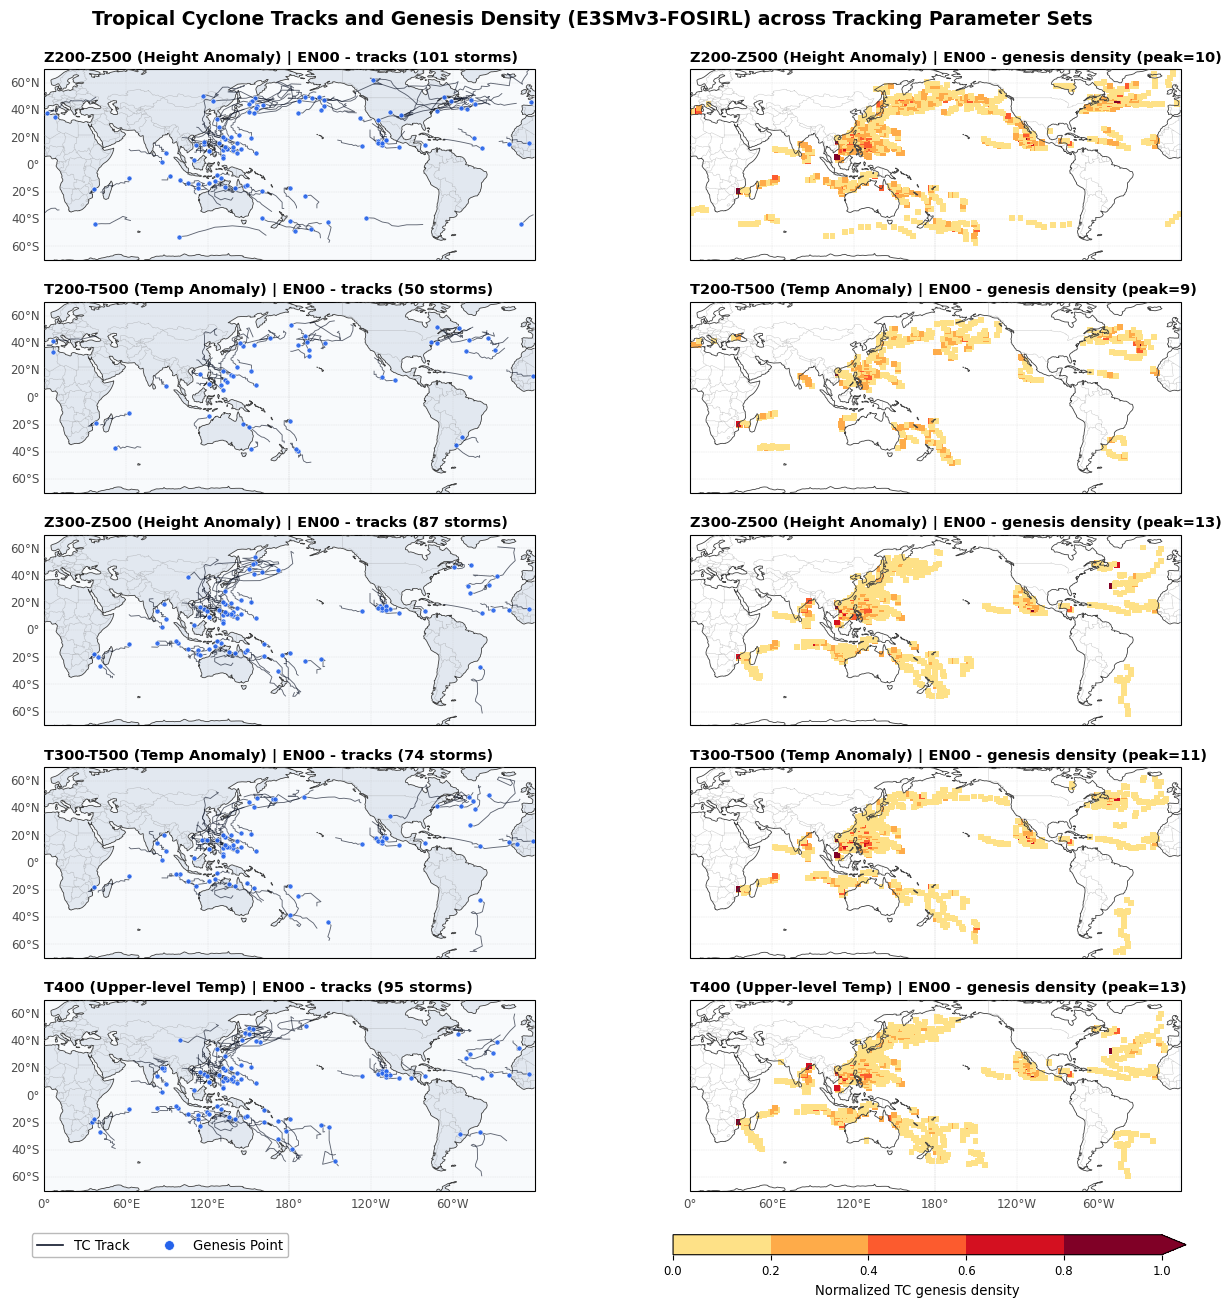

In [6]:
# Quick sanity plot: compare one HistogramNodes/Track pair for each tracking set
# =================================================================== #
#  SETUP & PLOT CONTROLS
# =================================================================== #
QUICK_SANITY_PARSETS = ["set1", "set2", "set3", "set4", "set5"]
QUICK_SANITY_EXTENT = [0, 360, -70, 70]
QUICK_SANITY_CENTRAL_LONGITUDE = 180

# Figure title, sizing & output
QUICK_SANITY_FIG_TITLE = f"Tropical Cyclone Tracks and Genesis Density ({label}) across Tracking Parameter Sets"
QUICK_SANITY_FIG_WIDTH = 13.5
QUICK_SANITY_ROW_HEIGHT = 2.45
QUICK_SANITY_EXTRA_HEIGHT = 1.1
QUICK_SANITY_DPI = 200

# Figure saving and metadata
QUICK_SANITY_METRIC = "tc_tracks_density_sanity_compare"
QUICK_SANITY_SAVE_MODE = "tc"
QUICK_SANITY_SAVE_TITLE = f"TC Tracks and Genesis Density Sensitivity Check ({label})"
QUICK_SANITY_SAVE_CAPTION = f"Sensitivity of simulated TC tracks and genesis density to tracking configurations ({label})."
QUICK_SANITY_SAVE_KW = dict(
    mode=QUICK_SANITY_SAVE_MODE,
    metric=QUICK_SANITY_METRIC,
    title=QUICK_SANITY_SAVE_TITLE,
    caption=QUICK_SANITY_SAVE_CAPTION,
    dpi=QUICK_SANITY_DPI,
)

# Typography / Font sizes
QUICK_SANITY_FONTSIZE = 12.0
QUICK_SANITY_TITLE_FONTSIZE = 13.5
QUICK_SANITY_PANEL_FONTSIZE = 10.5
QUICK_SANITY_LABEL_FONTSIZE = 9.5
QUICK_SANITY_TICK_FONTSIZE = 8.5
QUICK_SANITY_ANNOTATION_FONTSIZE = 10.0

# Colormap, density levels & normalization
QUICK_SANITY_CMAP_NAME = "YlOrRd"
QUICK_SANITY_CMAP_START = 0.20
QUICK_SANITY_COLOR_LEVELS = np.arange(0, 1.01, 0.2)
QUICK_SANITY_COLORBAR_TICKS = np.arange(0, 1.01, 0.2)
QUICK_SANITY_COLORBAR_LABEL = "Normalized TC genesis density"
QUICK_SANITY_DENSITY_ALPHA = 1.0
QUICK_SANITY_NORMALIZE_DENSITY = True

QUICK_SANITY_DENSITY_MARKER_SIZE = 18
QUICK_SANITY_DENSITY_MARKER = "s"

# Layout & positioning
QUICK_SANITY_SUBPLOTS_ADJUST = dict(left=0.05, right=0.98, top=0.93, bottom=0.09, wspace=0.06, hspace=0.22)
QUICK_SANITY_COLORBAR_AX = [0.56, 0.042, 0.38, 0.015]  # [left, bottom, width, height]

# Legend configuration
QUICK_SANITY_LEGEND_TRACK_LABEL = "TC Track"
QUICK_SANITY_LEGEND_TRACK_LW = 1.2
QUICK_SANITY_LEGEND_GENESIS_LABEL = "Genesis Point"
QUICK_SANITY_LEGEND_GENESIS_SIZE = 7
QUICK_SANITY_LEGEND_GENESIS_EDGEWIDTH = 0.5
QUICK_SANITY_LEGEND_KW = dict(
    loc="lower left",
    bbox_to_anchor=(0.08, 0.035),
    ncol=2,
    frameon=True,
    framealpha=0.9,
    edgecolor="0.7",
    fontsize=QUICK_SANITY_LABEL_FONTSIZE,
)

# Colorbar configuration
QUICK_SANITY_COLORBAR_KW = dict(
    orientation="horizontal",
    extend="max",
)

# Map and track styling
QUICK_SANITY_COASTLINE_KW = dict(linewidth=0.6, color="0.25", zorder=3)
QUICK_SANITY_BORDER_KW = dict(linewidth=0.3, edgecolor="0.5", alpha=0.5, zorder=3)
QUICK_SANITY_GRIDLINE_KW = dict(linewidth=0.3, color="0.75", alpha=0.5, linestyle="--", zorder=3)
QUICK_SANITY_TRACK_KW = dict(colors="#0f172a", linewidths=0.65, alpha=0.65)
QUICK_SANITY_GENESIS_KW = dict(
    s=13, marker="o", color="#2563eb", edgecolor="white", linewidth=0.4, alpha=0.9
)

# =================================================================== #
#  DATA RETRIEVAL & PROCESSING
# =================================================================== #
quick_panels = []
_quick_sanity_expected = len(CASES) * len(members_avail)

for pset in QUICK_SANITY_PARSETS:
    hist_files = []
    missing_pairs = []
    for case in CASES:
        for member in members_avail:
            analysis_dir = TRACK_DIR / case / member / "post" / "atm" / "tc-analysis"
            hist_file = analysis_dir / f"{case}_{member}_{pset}_TCS_hist.nc"
            if hist_file.is_file():
                hist_files.append({"case": case, "member": member, "path": hist_file})
            else:
                missing_pairs.append((case, member))

    print(f"[{pset}] Found {len(hist_files)} of {_quick_sanity_expected} expected histogram files")
    if missing_pairs:
        preview = ", ".join(f"{c}/{m}" for c, m in missing_pairs[:5])
        more = "" if len(missing_pairs) <= 5 else f" ... ({len(missing_pairs) - 5} more)"
        print(f"[{pset}] Missing: {preview}{more}")

    if not hist_files:
        continue

    sample = hist_files[0]
    case = sample["case"]
    member = sample["member"]
    hist_file = sample["path"]
    analysis_dir = hist_file.parent
    track_file = analysis_dir / f"{case}_{member}_{pset}_TCS_track.txt"
    if not track_file.is_file():
        track_file = None

    ds_hist = xr.open_dataset(hist_file)
    try:
        varname = "density"
        if varname not in ds_hist.data_vars:
            raise KeyError(
                f"Expected variable {varname!r} in histogram file {hist_file}; "
                f"found data vars: {list(ds_hist.data_vars)}"
            )
        density = ds_hist[varname]
        extra_dims = [d for d in density.dims if d not in ("lat", "lon")]
        if extra_dims:
            density = density.sum(dim=extra_dims)
        density = density.load()
    finally:
        ds_hist.close()

    lon2d, lat2d = np.meshgrid(density["lon"].values, density["lat"].values)
    land_mask = xr.DataArray(
        globe.is_land(lat2d, ((lon2d + 180.0) % 360.0) - 180.0),
        coords=density.coords,
        dims=density.dims,
    )

    plot_density = density.where((density > 0) & (~land_mask))
    land_points = float(density.where(land_mask).sum())
    max_density = float(plot_density.max(skipna=True))

    if QUICK_SANITY_NORMALIZE_DENSITY and np.isfinite(max_density) and max_density > 0:
        plot_density_for_plot = plot_density / max_density
    else:
        plot_density_for_plot = plot_density

    tracks = read_stitch_nodes_tracks([track_file]) if track_file is not None else pd.DataFrame()
    n_storms = (
        tracks[["case", "member", "storm_id"]].drop_duplicates().shape[0]
        if not tracks.empty
        else 0
    )

    n_nonzero_cells = int(((density > 0) & (~land_mask)).sum())
    print(f"[{pset}] Histogram: {hist_file}")
    print(f"[{pset}] Track    : {track_file if track_file is not None else 'not found'}")
    print(
        f"[{pset}] {varname!r}: total={float(density.sum()):.0f}, "
        f"land_points={land_points:.0f}, ocean nonzero cells={n_nonzero_cells}, "
        f"max={max_density:.0f}; tracks={n_storms}, points={len(tracks)}"
    )
    print(
        f"[{pset}] plotted density: nonzero={int(np.isfinite(plot_density_for_plot.values).sum())}, "
        f"min={float(plot_density_for_plot.min(skipna=True)):.3g}, "
        f"max={float(plot_density_for_plot.max(skipna=True)):.3g}"
    )
    if n_nonzero_cells == 0:
        print(
            f"[{pset}] WARNING: no nonzero ocean cells in {varname!r} — the density "
            f"panel will be blank.  Check that {hist_file.name} actually has track data."
        )

    quick_panels.append(
        {
            "pset": pset,
            "case": case,
            "member": member,
            "hist_file": hist_file,
            "track_file": track_file,
            "plot_density_for_plot": plot_density_for_plot,
            "max_density": max_density,
            "tracks": tracks,
        }
    )

# =================================================================== #
#  PLOTTING
# =================================================================== #
if not quick_panels:
    print("No histogram files found for any quick sanity set - run the input ensure cell first.")
else:
    levels = np.asarray(QUICK_SANITY_COLOR_LEVELS)
    base_cmap = plt.get_cmap(QUICK_SANITY_CMAP_NAME)
    cmap = ListedColormap(
        base_cmap(np.linspace(QUICK_SANITY_CMAP_START, 1.0, len(levels) - 1))
    )
    cmap.set_bad((1, 1, 1, 0))
    cmap.set_over(base_cmap(1.0))
    norm = BoundaryNorm(levels, cmap.N)
    nrows = len(quick_panels)
    fig, axes = plt.subplots(
        nrows,
        2,
        figsize=(QUICK_SANITY_FIG_WIDTH, QUICK_SANITY_ROW_HEIGHT * nrows + QUICK_SANITY_EXTRA_HEIGHT),
        subplot_kw={
            "projection": ccrs.PlateCarree(
                central_longitude=QUICK_SANITY_CENTRAL_LONGITUDE
            )
        },
        squeeze=False,
    )
    im = None

    for row, panel in enumerate(quick_panels):
        pset = panel["pset"]
        pset_display = PSET_DISPLAY_NAMES.get(pset, pset)
        panel_label = f"{pset_display} | {panel['member']}"
        is_last_row = (row == nrows - 1)

        track_ax = axes[row, 0]
        density_ax = axes[row, 1]

        # Tracks
        n_storms, n_points = _plot_tracks(track_ax, panel["tracks"])
        track_title = f"{panel_label} - tracks ({n_storms} storms)"
        _setup_map_axis(
            track_ax,
            track_title,
            extent=QUICK_SANITY_EXTENT,
            show_bottom_labels=is_last_row,
            show_left_labels=True,
            title_fontsize=QUICK_SANITY_PANEL_FONTSIZE,
            tick_fontsize=QUICK_SANITY_TICK_FONTSIZE,
        )

        # Density
        density_da = panel["plot_density_for_plot"]
        max_d = panel["max_density"]
        has_density = (
            np.isfinite(max_d)
            and max_d > 0
            and np.isfinite(density_da.values).any()
        )
        density_title = f"{panel_label} - genesis density (peak={int(max_d) if np.isfinite(max_d) else 0})"
        _setup_map_axis(
            density_ax,
            density_title,
            extent=QUICK_SANITY_EXTENT,
            show_bottom_labels=is_last_row,
            show_left_labels=False,
            title_fontsize=QUICK_SANITY_PANEL_FONTSIZE,
            tick_fontsize=QUICK_SANITY_TICK_FONTSIZE,
        )

        if has_density:
            density_values, density_lon = add_cyclic_point(
                density_da.values,
                coord=density_da["lon"].values,
                axis=1,
            )
            lon2d, lat2d = np.meshgrid(density_lon, density_da["lat"].values)
            im = density_ax.pcolormesh(
                lon2d,
                lat2d,
                density_values,
                transform=ccrs.PlateCarree(),
                cmap=cmap,
                norm=norm,
                shading="auto",
                alpha=QUICK_SANITY_DENSITY_ALPHA,
                zorder=1,
                rasterized=True,
            )

            lon_vals = density_da["lon"].values
            lat_vals = density_da["lat"].values
            lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)
            values = density_da.values
            finite_mask = np.isfinite(values)
            if finite_mask.any():
                density_ax.scatter(
                    lon_grid[finite_mask],
                    lat_grid[finite_mask],
                    c=values[finite_mask],
                    cmap=cmap,
                    norm=norm,
                    transform=ccrs.PlateCarree(),
                    s=QUICK_SANITY_DENSITY_MARKER_SIZE,
                    marker=QUICK_SANITY_DENSITY_MARKER,
                    linewidths=0,
                    zorder=2,
                )
        else:
            density_ax.text(
                0.5,
                0.5,
                "no density data",
                transform=density_ax.transAxes,
                ha="center",
                va="center",
                fontsize=QUICK_SANITY_ANNOTATION_FONTSIZE,
                color="0.4",
            )

    fig.subplots_adjust(**QUICK_SANITY_SUBPLOTS_ADJUST)

    # Track legend under tracks column (left bottom)
    legend_elements = [
        Line2D([0], [0], color=QUICK_SANITY_TRACK_KW["colors"], lw=QUICK_SANITY_LEGEND_TRACK_LW, label=QUICK_SANITY_LEGEND_TRACK_LABEL),
        Line2D(
            [0], [0],
            marker=QUICK_SANITY_GENESIS_KW["marker"],
            color="none",
            markerfacecolor=QUICK_SANITY_GENESIS_KW["color"],
            markeredgecolor="white",
            markeredgewidth=QUICK_SANITY_LEGEND_GENESIS_EDGEWIDTH,
            markersize=QUICK_SANITY_LEGEND_GENESIS_SIZE,
            label=QUICK_SANITY_LEGEND_GENESIS_LABEL,
        ),
    ]
    fig.legend(
        handles=legend_elements,
        **QUICK_SANITY_LEGEND_KW,
    )

    # Colorbar under density column (right bottom)
    if im is not None:
        cbar_ax = fig.add_axes(QUICK_SANITY_COLORBAR_AX)
        cbar = fig.colorbar(
            im,
            cax=cbar_ax,
            ticks=QUICK_SANITY_COLORBAR_TICKS,
            boundaries=levels,
            **QUICK_SANITY_COLORBAR_KW,
        )
        cbar.set_label(
            QUICK_SANITY_COLORBAR_LABEL,
            fontsize=QUICK_SANITY_LABEL_FONTSIZE,
        )
        cbar.ax.tick_params(labelsize=QUICK_SANITY_TICK_FONTSIZE)

    fig.suptitle(
        QUICK_SANITY_FIG_TITLE,
        fontsize=QUICK_SANITY_TITLE_FONTSIZE,
        fontweight="bold",
        y=0.975,
    )
    import esp_lab.utils.mov_utils as mov
    figname = figure_filename(QUICK_SANITY_METRIC, case)
    figpath = FIGURE_OUTDIR / figname
    mov.save_figure(fig, figpath, **QUICK_SANITY_SAVE_KW)
    print("Saved figure:", figpath)
    plt.show()



May initializations: 39 cases x 10 members
[May set1] Found 390 of 390 expected histogram files
[May set2] Found 390 of 390 expected histogram files
[May set3] Found 390 of 390 expected histogram files
[May set4] Found 390 of 390 expected histogram files
[May set5] Found 390 of 390 expected histogram files

November initializations: 39 cases x 10 members
[November set1] Found 390 of 390 expected histogram files
[November set2] Found 390 of 390 expected histogram files
[November set3] Found 390 of 390 expected histogram files
[November set4] Found 390 of 390 expected histogram files
[November set5] Found 390 of 390 expected histogram files
[May set1] Plotting mean 'density': total=1805.23, land-masked=229.42, ocean cells=10994, max_ocean=2.92
[November set1] Plotting mean 'density': total=1914.03, land-masked=234.74, ocean cells=11215, max_ocean=2.89
[May set2] Plotting mean 'density': total=968.50, land-masked=92.41, ocean cells=10453, max_ocean=1.07
[November set2] Plotting mean 'den

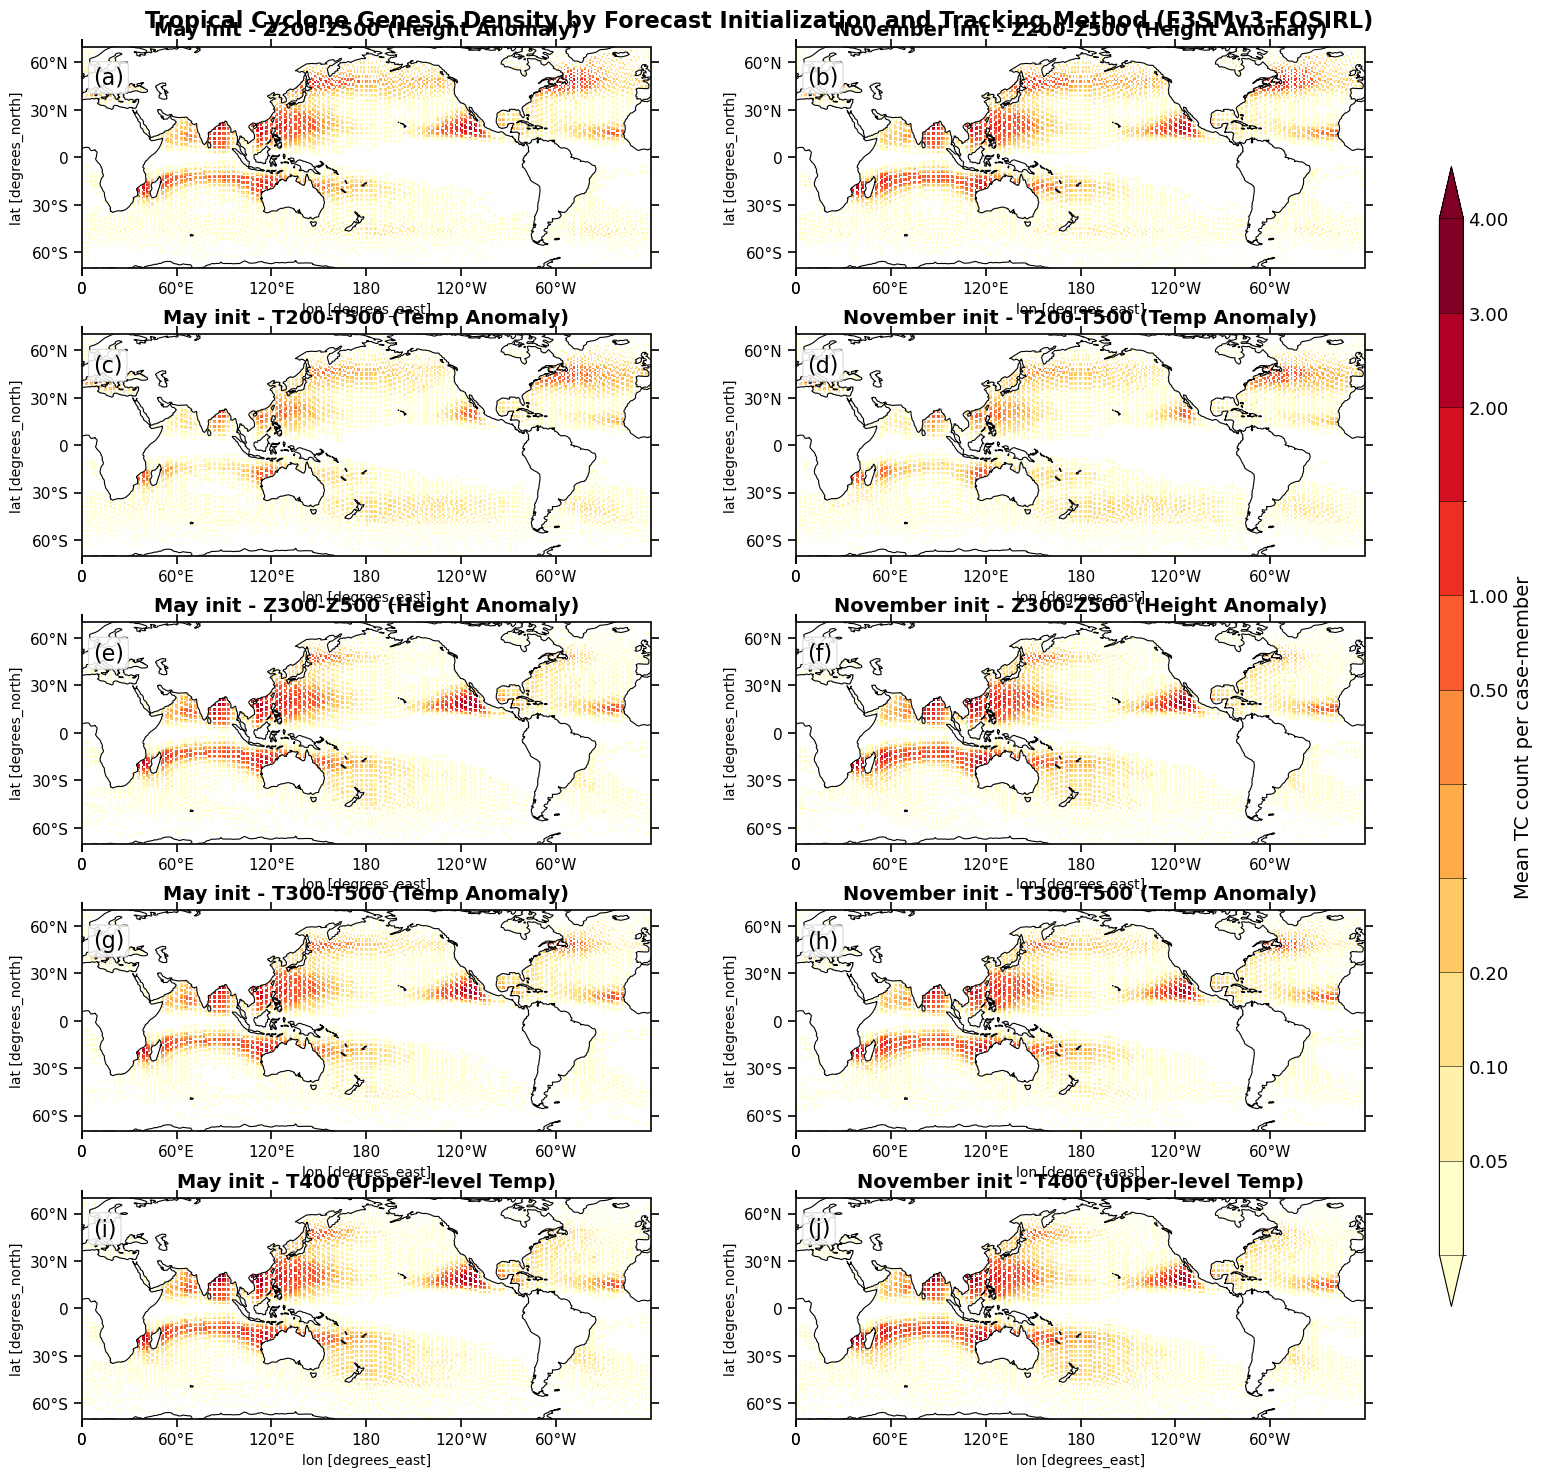

In [7]:
# Plot TC genesis density from HistogramNodes output by initialization month
import esp_lab.utils.mov_utils as mov

def _case_init_month(case):
    return int(str(case).rsplit("_", 1)[-1][4:6])

# =================================================================== #
#  SETUP & PLOT CONTROLS
# =================================================================== #
# Parameter sets and initialization months to plot
GENESIS_PARSETS = ["set1", "set2", "set3", "set4", "set5"]
GENESIS_INIT_MONTHS = [5, 11]
GENESIS_INIT_LABELS = {5: "May", 11: "November"}

# Map extent & projection
GENESIS_MAP_EXTENT = [0, 360, -70, 70]
GENESIS_CENTRAL_LONGITUDE = 180

# Colorbar & contour levels
GENESIS_COLOR_LEVELS = np.array([0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0])
GENESIS_COLORBAR_TICKS = [0.05, 0.1, 0.2, 0.5, 1, 2, 3, 4]
GENESIS_CMAP_NAME = "YlOrRd"
GENESIS_COLORBAR_LABEL = "Mean TC count per case-member"
GENESIS_COLORBAR_AX = [0.925, 0.12, 0.015, 0.76]  # [left, bottom, width, height]
GENESIS_COLORBAR_KW = dict(
    orientation="vertical",
    drawedges=True,
)
GENESIS_COLORBAR_TICK_PARAMS = dict(
    labelsize=13,
    length=0,
)

# Figure dimensions & layout
GENESIS_SUBPLOT_WIDTH = 8.0
GENESIS_SUBPLOT_HEIGHT = 3.0
GENESIS_SUBPLOTS_ADJUST = dict(left=0.055, right=0.90, top=0.96, bottom=0.045, hspace=0.30, wspace=0.12)

# Typography & styling
GENESIS_FIG_TITLE = f"Tropical Cyclone Genesis Density by Forecast Initialization and Tracking Method ({label})"
GENESIS_TITLE_FONTSIZE = 16
GENESIS_PANEL_TITLE_FONTSIZE = 14
GENESIS_LABEL_FONTSIZE = 14
GENESIS_TICK_FONTSIZE = 11
GENESIS_LETTER_FONTSIZE = 16
GENESIS_LETTER_BBOX = dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="lightgray", alpha=0.85, linewidth=0.8)
GENESIS_NO_FILES_BBOX = dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.7", alpha=0.9)
GENESIS_COASTLINE_WIDTH = 0.8
GENESIS_SPINE_WIDTH = 1.2

# Coordinate grid ticks
GENESIS_XTICKS = np.arange(0, 361, 60)
GENESIS_XTICK_LABELS = ["0", "60°E", "120°E", "180", "120°W", "60°W", "0"]
GENESIS_YTICKS = [-60, -30, 0, 30, 60]
GENESIS_YTICK_LABELS = ["60°S", "30°S", "0", "30°N", "60°N"]

# Output & Figure saving metadata
GENESIS_DPI = 200
GENESIS_METRIC = "tc_genesis_density_method_compare"
GENESIS_SAVE_MODE = "tc"
GENESIS_SAVE_TITLE = f"TC Genesis Density Method Comparison ({label})"
GENESIS_SAVE_CAPTION = f"Mean TC genesis density comparison by forecast initialization month and tracking method ({label})."
GENESIS_SAVE_KW = dict(
    mode=GENESIS_SAVE_MODE,
    metric=GENESIS_METRIC,
    title=GENESIS_SAVE_TITLE,
    caption=GENESIS_SAVE_CAPTION,
    dpi=GENESIS_DPI,
)

# =================================================================== #
#  DATA RETRIEVAL & PROCESSING
# =================================================================== #
hist_files_by_init_and_pset = {}
for init_month in GENESIS_INIT_MONTHS:
    init_label = GENESIS_INIT_LABELS.get(init_month, f"month {init_month:02d}")
    cases_for_init = [case for case in CASES if _case_init_month(case) == init_month]
    expected_per_pset = len(cases_for_init) * len(members_avail)
    hist_files_by_pset = {}

    print(f"\n{init_label} initializations: {len(cases_for_init)} cases x {len(members_avail)} members")
    for pset in GENESIS_PARSETS:
        files_for_pset = []
        missing_pairs = []
        for case in cases_for_init:
            for member in members_avail:
                analysis_dir = TRACK_DIR / case / member / "post" / "atm" / "tc-analysis"
                hist_file = analysis_dir / f"{case}_{member}_{pset}_TCS_hist.nc"
                if hist_file.is_file():
                    files_for_pset.append(hist_file)
                else:
                    missing_pairs.append((case, member))

        print(f"[{init_label} {pset}] Found {len(files_for_pset)} of {expected_per_pset} expected histogram files")
        if missing_pairs:
            preview = ", ".join(f"{c}/{m}" for c, m in missing_pairs[:5])
            more = "" if len(missing_pairs) <= 5 else f" ... ({len(missing_pairs) - 5} more)"
            print(f"[{init_label} {pset}] Missing: {preview}{more}")

        hist_files_by_pset[pset] = files_for_pset

    hist_files_by_init_and_pset[init_month] = hist_files_by_pset

# =================================================================== #
#  PLOTTING
# =================================================================== #
if not any(
    hist_files
    for files_by_pset in hist_files_by_init_and_pset.values()
    for hist_files in files_by_pset.values()
):
    print("No histogram files found for May or November initializations — run the input ensure cell first.")
else:
    n_rows = len(GENESIS_PARSETS)
    n_cols = len(GENESIS_INIT_MONTHS)
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(GENESIS_SUBPLOT_WIDTH * n_cols, GENESIS_SUBPLOT_HEIGHT * n_rows),
        subplot_kw={"projection": ccrs.PlateCarree(central_longitude=GENESIS_CENTRAL_LONGITUDE)},
        squeeze=False
    )

    levels = GENESIS_COLOR_LEVELS
    colorbar_ticks = GENESIS_COLORBAR_TICKS
    cmap = plt.get_cmap(GENESIS_CMAP_NAME, len(levels) - 1).copy()
    cmap.set_bad((1, 1, 1, 0))
    im = None

    for row, pset in enumerate(GENESIS_PARSETS):
        for col, init_month in enumerate(GENESIS_INIT_MONTHS):
            init_label = GENESIS_INIT_LABELS.get(init_month, f"month {init_month:02d}")
            hist_files = hist_files_by_init_and_pset.get(init_month, {}).get(pset, [])
            ax = axes[row, col]

            ax.set_extent(GENESIS_MAP_EXTENT, crs=ccrs.PlateCarree())

            ax.set_xticks(GENESIS_XTICKS, crs=ccrs.PlateCarree())
            ax.set_xticklabels(GENESIS_XTICK_LABELS, fontsize=GENESIS_TICK_FONTSIZE)
            ax.set_yticks(GENESIS_YTICKS, crs=ccrs.PlateCarree())
            ax.set_yticklabels(GENESIS_YTICK_LABELS, fontsize=GENESIS_TICK_FONTSIZE)

            ax.tick_params(axis="both", which="major", direction="out", length=6, width=1.2,
                           top=True, right=True, labeltop=False, labelright=False)
            for spine in ax.spines.values():
                spine.set_linewidth(GENESIS_SPINE_WIDTH)
            ax.coastlines(linewidth=GENESIS_COASTLINE_WIDTH, color="black")

            if not hist_files:
                ax.text(
                    0.5, 0.5, "no histogram files", transform=ax.transAxes,
                    ha="center", va="center", fontsize=14, color="0.35",
                    bbox=GENESIS_NO_FILES_BBOX,
                )
                continue

            ds_hist = xr.open_mfdataset(
                hist_files,
                combine="nested",
                concat_dim="hist_file",
                coords="minimal",
                compat="override",
                combine_attrs="override",
            )
            try:
                # HistogramNodes always writes a 'density' variable; silently
                # falling back to an arbitrary variable could produce a
                # scientifically incorrect figure.
                if "density" not in ds_hist.data_vars:
                    raise KeyError(
                        f"Expected 'density' in histogram files for {pset}; "
                        f"found {list(ds_hist.data_vars)}"
                    )
                density = ds_hist["density"]
                if "hist_file" in density.dims:
                    density = density.mean(dim="hist_file")
                extra_dims = [d for d in density.dims if d not in ("lat", "lon")]
                if extra_dims:
                    density = density.sum(dim=extra_dims)
                density = density.load()
            finally:
                ds_hist.close()

            lon2d, lat2d = np.meshgrid(density["lon"].values, density["lat"].values)
            land_mask = xr.DataArray(
                globe.is_land(lat2d, ((lon2d + 180.0) % 360.0) - 180.0),
                coords=density.coords,
                dims=density.dims,
            )
            land_points = float(density.where(land_mask).sum())
            plot_density = density.where((density > 0) & (~land_mask))
            print(
                f"[{init_label} {pset}] Plotting mean 'density': total={float(density.sum()):.2f}, "
                f"land-masked={land_points:.2f}, ocean cells={int(((density > 0) & (~land_mask)).sum())}, "
                f"max_ocean={float(plot_density.max(skipna=True)):.2f}"
            )

            im = plot_density.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap=cmap,
                levels=levels,
                extend="both",
                add_colorbar=False,
            )
            pset_display = PSET_DISPLAY_NAMES.get(pset, pset)
            ax.set_title(f"{init_label} init - {pset_display}", fontsize=GENESIS_PANEL_TITLE_FONTSIZE, fontweight="bold", pad=8)

            letter = chr(ord('a') + row * n_cols + col)
            ax.text(
                0.02, 0.86, f"({letter})", transform=ax.transAxes,
                fontsize=GENESIS_LETTER_FONTSIZE, ha="left", va="center",
                bbox=GENESIS_LETTER_BBOX,
            )

    fig.subplots_adjust(**GENESIS_SUBPLOTS_ADJUST)
    if im is not None:
        cbar_ax = fig.add_axes(GENESIS_COLORBAR_AX)
        cbar = fig.colorbar(
            im, cax=cbar_ax,
            ticks=colorbar_ticks,
            **GENESIS_COLORBAR_KW,
        )
        cbar.set_label(GENESIS_COLORBAR_LABEL, fontsize=GENESIS_LABEL_FONTSIZE)
        cbar.ax.tick_params(**GENESIS_COLORBAR_TICK_PARAMS)
    fig.suptitle(GENESIS_FIG_TITLE, fontsize=GENESIS_TITLE_FONTSIZE, fontweight="bold", y=0.985)

    figname = figure_filename(GENESIS_METRIC, case)
    figpath = FIGURE_OUTDIR / figname
    mov.save_figure(fig, figpath, **GENESIS_SAVE_KW)
    print("Saved figure:", figpath)
    plt.show()


In [8]:
def _case_year(case_name):
    match = re.search(r"_(\d{10})$", str(case_name))
    return int(match.group(1)[:4]) if match else None


def _filter_cases_by_year(cases, start_year=None, end_year=None):
    selected = []
    for case in cases:
        year = _case_year(case)
        if start_year is not None and year is not None and year < start_year:
            continue
        if end_year is not None and year is not None and year > end_year:
            continue
        selected.append(case)
    return selected


def _read_ibtracs_tracks(path, start_year=None, end_year=None, wind_min_kt=34.0, time_step_hours=6):
    """Return an IBTrACS point table for trajectory plotting."""
    ds_obs = xr.open_dataset(path)
    wind = xr.where(np.isfinite(ds_obs["wmo_wind"]), ds_obs["wmo_wind"], ds_obs["usa_wind"])

    lat_da = ds_obs["lat"]
    storm_dim, point_dim = lat_da.dims[:2]
    storm_id = np.repeat(np.arange(lat_da.sizes[storm_dim]), lat_da.sizes[point_dim])

    lat = lat_da.values.ravel()
    lon = ds_obs["lon"].values.ravel() % 360.0
    time = pd.to_datetime(ds_obs["time"].values.ravel())
    wind_kt = wind.values.ravel()

    valid = ~pd.isna(time) & np.isfinite(lat) & np.isfinite(lon)
    if wind_min_kt is not None:
        valid &= np.isfinite(wind_kt) & (wind_kt >= wind_min_kt)

    obs = pd.DataFrame({
        "storm_id": storm_id[valid],
        "time": time[valid],
        "lat": lat[valid],
        "lon": lon[valid],
        "wind_kt": wind_kt[valid],
    })

    if time_step_hours is not None and not obs.empty:
        obs = obs[
            obs["time"].dt.minute.eq(0)
            & obs["time"].dt.second.eq(0)
            & obs["time"].dt.hour.mod(time_step_hours).eq(0)
        ].copy()

    if start_year is not None and not obs.empty:
        obs = obs[obs["time"].dt.year >= start_year].copy()
    if end_year is not None and not obs.empty:
        obs = obs[obs["time"].dt.year <= end_year].copy()

    return obs


def _infer_model_wind_kt(df, wind_col="wind"):
    """Convert model wind to kt; TempestExtremes runner writes m/s for this column."""
    wind = pd.to_numeric(df[wind_col], errors="coerce")
    if wind.dropna().empty:
        return wind

    # The runner threshold is configured in m/s. If a future file is already in kt,
    # avoid double conversion by checking the upper distribution.
    p99 = float(wind.quantile(0.99))
    return wind * 1.943844492 if p99 < 90.0 else wind


def _category_color(wind_kt, include_weak_as_ts=False):
    if not np.isfinite(wind_kt):
        return None
    if include_weak_as_ts and wind_kt < TC_CATEGORIES[1][1]:
        return TC_CATEGORIES[0][3]
    for _, lo, hi, color in TC_CATEGORIES:
        if lo <= wind_kt < hi:
            return color
    return None


def _thin_tracks(df, group_cols, max_tracks=None, random_seed=42):
    if max_tracks is None or df.empty:
        return df

    keys = df[group_cols].drop_duplicates()
    if len(keys) <= max_tracks:
        return df

    sampled = keys.sample(n=max_tracks, random_state=random_seed)
    return df.merge(sampled, on=group_cols, how="inner")


def _plot_category_tracks(ax, df, group_cols, wind_col="wind_kt", include_weak_as_ts=False):
    if df.empty:
        ax.text(0.5, 0.5, "no tracks", transform=ax.transAxes, ha="center", va="center", fontsize=11)
        return 0, 0

    n_tracks = 0
    n_segments = 0
    for _, group in df.sort_values("time").groupby(group_cols):
        group = group.dropna(subset=["lon", "lat", wind_col])
        if len(group) < 2:
            continue

        points = group[["lon", "lat"]].to_numpy(dtype=float)
        winds = group[wind_col].to_numpy(dtype=float)
        segments_by_color = {}

        for i in range(len(points) - 1):
            lon0, lat0 = points[i]
            lon1, lat1 = points[i + 1]
            if not np.all(np.isfinite([lon0, lat0, lon1, lat1])):
                continue
            if (lat0 < -60.0 or lat0 > 60.0 or lat1 < -60.0 or lat1 > 60.0):
                continue

            # Do not draw long wraparound lines across the map boundary.
            if abs(lon1 - lon0) > 180.0:
                continue

            color = _category_color(np.nanmax([winds[i], winds[i + 1]]), include_weak_as_ts=include_weak_as_ts)
            if color is None:
                continue

            segments_by_color.setdefault(color, []).append([(lon0, lat0), (lon1, lat1)])
            n_segments += 1

        for color, segments in segments_by_color.items():
            collection = LineCollection(
                segments,
                colors=color,
                linewidths=0.55,
                alpha=0.58,
                transform=ccrs.PlateCarree(),
                zorder=3,
            )
            ax.add_collection(collection)

        n_tracks += 1

    if n_segments == 0:
        ax.text(0.5, 0.5, "no categorized segments", transform=ax.transAxes, ha="center", va="center", fontsize=11)

    return n_tracks, n_segments


def _format_track_axis(ax, panel_label, title, row, col, n_rows, n_cols):
    extent = globals().get("TRACK_MAP_EXTENT", globals().get("TRACK_PANEL_EXTENT", [30, 360, -60, 60]))
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ocean_color = globals().get("TRACK_OCEAN_FACECOLOR", "#bdeffc")
    ax.set_facecolor(ocean_color)
    land_kw = globals().get("TRACK_LAND_KW", dict(facecolor="#d2b48c", edgecolor="0.35", linewidth=0.45, zorder=1))
    ax.add_feature(cfeature.LAND.with_scale("110m"), **land_kw)
    coast_kw = globals().get("TRACK_COASTLINE_KW", dict(linewidth=0.45, edgecolor="0.30", zorder=2))
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"), **coast_kw)

    xticks = globals().get("TRACK_XTICKS", [30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360])
    xtick_labels = globals().get("TRACK_XTICK_LABELS", ["30E", "60E", "90E", "120E", "150E", "180", "150W", "120W", "90W", "60W", "30W", "0"])
    yticks = globals().get("TRACK_YTICKS", [-60, -30, 0, 30, 60])
    ytick_labels = globals().get("TRACK_YTICK_LABELS", ["60S", "30S", "0", "30N", "60N"])
    tick_fontsize = globals().get("TRACK_TICK_FONTSIZE", 8)

    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    if row == n_rows - 1:
        ax.set_xticklabels(xtick_labels, fontsize=tick_fontsize)
    else:
        ax.set_xticklabels([], fontsize=tick_fontsize)
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    if col == 0:
        ax.set_yticklabels(ytick_labels, fontsize=tick_fontsize)
    else:
        ax.set_yticklabels([], fontsize=tick_fontsize)

    tick_params = globals().get("TRACK_TICK_PARAMS", dict(axis="both", which="major", direction="out", length=5, width=0.8, top=True, right=True))
    ax.tick_params(**tick_params)
    ax.minorticks_on()

    bbox = globals().get("TRACK_LABEL_BBOX", dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="0.65", alpha=0.85, linewidth=0.6))
    label_fontsize = globals().get("TRACK_PANEL_LABEL_FONTSIZE", 11)
    title_fontsize = globals().get("TRACK_PANEL_TITLE_FONTSIZE", 9.5)
    ax.text(0.008, 0.05, panel_label, transform=ax.transAxes, fontsize=label_fontsize, fontweight="bold", ha="left", va="bottom", bbox=bbox, zorder=12)
    ax.text(0.5, 0.05, title, transform=ax.transAxes, fontsize=title_fontsize, fontweight="bold", ha="center", va="bottom", bbox=bbox, zorder=12)

    spine_width = globals().get("TRACK_SPINE_WIDTH", 0.9)
    for spine in ax.spines.values():
        spine.set_linewidth(spine_width)


def _case_init_time(case_name):
    match = re.search(r"_(\d{10})$", str(case_name))
    return pd.to_datetime(match.group(1), format="%Y%m%d%H") if match else pd.NaT


def _filter_model_by_lead_year(df, lead_year):
    if df.empty:
        return df
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])
    out["init_time"] = pd.to_datetime(out["init_time"])
    start = out["init_time"] + pd.DateOffset(years=lead_year - 1)
    end = out["init_time"] + pd.DateOffset(years=lead_year)
    return out[(out["time"] >= start) & (out["time"] < end)].copy()


def _filter_obs_to_verifying_windows(obs, cases, lead_year):
    if obs.empty:
        return obs
    keep = np.zeros(len(obs), dtype=bool)
    obs_time = pd.to_datetime(obs["time"])
    for case in cases:
        init_time = _case_init_time(case)
        if pd.isna(init_time):
            continue
        start = init_time + pd.DateOffset(years=lead_year - 1)
        end = init_time + pd.DateOffset(years=lead_year)
        keep |= ((obs_time >= start) & (obs_time < end)).to_numpy()
    return obs.loc[keep].copy()


TC trajectory lead-year panels: 78 cases over 1980-2018 initializations
  IBTrACS Year 1: 3534 storms, 69737 points
  IBTrACS Year 2: 3552 storms, 69894 points

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
This can easily exceed memory/CPU limits and crash your Jupyter kernel.
We highly recommend launching Jupyter on an Exclusive Perlmutter Compute Node.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Scheduler: tcp://127.0.0.1:44053
Connected workers: 4
Dashboard: http://127.0.0.1:36711/status
Closed Dask resources after parallel track parsing.
  set1 Year 1: 780 files, 3534 plotted / 35346 total tracks, 70740 points
  set1 Year 2: 780 files, 3552 plotted / 37478 total tracks, 71360 points
  set2 Year 1: 780 files, 3534 plotted / 23805 total tracks, 56225 points
  set2 Year 2: 780 files, 3552 plotted / 24551 total tracks, 56650 points
  set3 Year 1: 780 files, 3534 plotted / 32397 total tracks, 76339 points
  set3 Ye

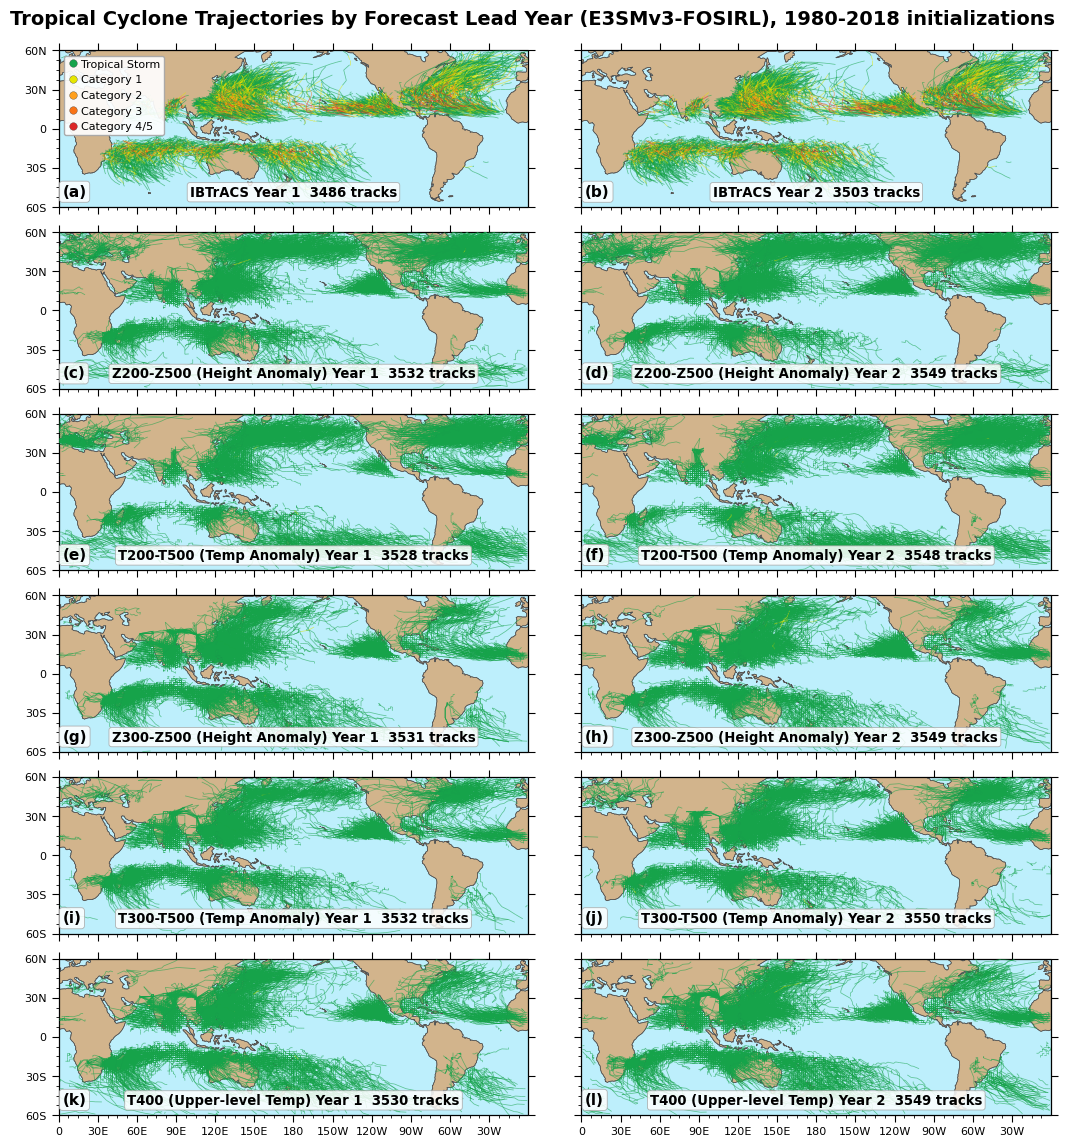

In [9]:
# Publication-style sanity plot: observed and method-set TC trajectories as stacked panels
sys.path.append(str(WORKFLOWS_DIR))
import esp_lab.utils.mov_utils as mov

# =================================================================== #
#  SETUP & PLOT CONTROLS
# =================================================================== #
# Forecast lead years & methods to plot
TRACK_LEAD_YEARS = [1, 2]
TRACK_LEAD_YEAR_LABELS = {1: "Year 1", 2: "Year 2"}
TRACK_PARSETS = ["set1", "set2", "set3", "set4", "set5"]

# Initialization year filtering
TRACK_CASES = globals().get("TRACK_PANEL_CASES", CASES)
TRACK_START_YEAR = globals().get("TRACK_PANEL_START_YEAR", globals().get("years", None))
TRACK_END_YEAR = globals().get("TRACK_PANEL_END_YEAR", globals().get("yeare", None))

# Track thinning and wind source settings
TRACK_WIND_SOURCE = globals().get("TRACK_PANEL_WIND_SOURCE", "wind")
TRACK_MAX_TRACKS_PER_PANEL = globals().get("TRACK_PANEL_MAX_TRACKS_PER_PANEL", None)
TRACK_MATCH_OBS_COUNT = globals().get("TRACK_PANEL_MATCH_OBS_TRACK_COUNT", True)
TRACK_RANDOM_SEED = globals().get("TRACK_PANEL_RANDOM_SEED", 42)

# Map extent & projection (30E-to-0 view, Pacific-centered)
TRACK_MAP_EXTENT = globals().get("TRACK_PANEL_EXTENT", [30, 360, -60, 60])
TRACK_CENTRAL_LONGITUDE = globals().get("TRACK_PANEL_CENTRAL_LONGITUDE", 180)
TRACK_OCEAN_FACECOLOR = "#bdeffc"
TRACK_LAND_KW = dict(facecolor="#d2b48c", edgecolor="0.35", linewidth=0.45, zorder=1)
TRACK_COASTLINE_KW = dict(linewidth=0.45, edgecolor="0.30", zorder=2)

# Coordinate grid ticks & labels
TRACK_XTICKS = [30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360]
TRACK_XTICK_LABELS = ["30E", "60E", "90E", "120E", "150E", "180", "150W", "120W", "90W", "60W", "30W", "0"]
TRACK_YTICKS = [-60, -30, 0, 30, 60]
TRACK_YTICK_LABELS = ["60S", "30S", "0", "30N", "60N"]
TRACK_TICK_PARAMS = dict(axis="both", which="major", direction="out", length=5, width=0.8, top=True, right=True)
TRACK_LABEL_BBOX = dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="0.65", alpha=0.85, linewidth=0.6)
TRACK_SPINE_WIDTH = 0.9

# IBTrACS reference data
IBTRACS_DEFAULT_FILE = Path("/global/cfs/cdirs/e3sm/S2S2D/IBTrACS/IBTrACS.since1980.v04r00.nc")
IBTRACS_TRACK_FILE = Path(globals().get("IBTRACS_FILE", IBTRACS_DEFAULT_FILE))
OBS_WIND_MIN_KT = globals().get("OBS_WIND_MIN_KT", 34.0)
OBS_TIME_STEP_HOURS = globals().get("OBS_TIME_STEP_HOURS", 6)

# Saffir-Simpson category thresholds in knots and colors
# Tropical Storm is 34-63 kt; Categories 4 and 5 are combined to match reference style.
TC_CATEGORIES = [
    ("Tropical Storm", 34.0, 64.0, "#16a34a"),
    ("Category 1", 64.0, 83.0, "#e6e600"),
    ("Category 2", 83.0, 96.0, "#ff9f1c"),
    ("Category 3", 96.0, 113.0, "#f97316"),
    ("Category 4/5", 113.0, np.inf, "#dc2626"),
]

# Figure dimensions & layout
TRACK_COL_WIDTH = 5.6
TRACK_ROW_HEIGHT = 1.95
TRACK_MIN_HEIGHT = 3.0
TRACK_SUBPLOTS_ADJUST = dict(left=0.06, right=0.98, top=0.95, bottom=0.04, hspace=0.16, wspace=0.03)

# Typography & styling
TRACK_TITLE_FONTSIZE = 14
TRACK_PANEL_TITLE_FONTSIZE = 9.5
TRACK_PANEL_LABEL_FONTSIZE = 11
TRACK_TICK_FONTSIZE = 8
TRACK_LINE_WIDTH = 0.55
TRACK_LINE_ALPHA = 0.58

# Legend configuration (fully parameterized)
TRACK_LEGEND_HANDLE_KW = dict(
    marker="o",
    linestyle="None",
    markersize=5.5,
    markeredgecolor="0.25",
    markeredgewidth=0.25,
)
TRACK_LEGEND_KW = dict(
    loc="upper left",
    frameon=True,
    framealpha=0.92,
    facecolor="white",
    edgecolor="0.65",
    fontsize=8,
    borderpad=0.3,
    handlelength=0.9,
    handletextpad=0.35,
)

# Output & Figure saving metadata
TRACK_DPI = 200
TRACK_METRIC = "tc_trajectory_compare"
TRACK_SAVE_MODE = "tc"
TRACK_SAVE_TITLE = f"TC Trajectory Tracking Method Comparison ({label})"
TRACK_SAVE_CAPTION = f"Comparison of observed and model-simulated TC tracks for parset {PARSET} ({label})"
TRACK_SAVE_KW = dict(
    mode=TRACK_SAVE_MODE,
    metric=TRACK_METRIC,
    title=TRACK_SAVE_TITLE,
    caption=TRACK_SAVE_CAPTION,
    dpi=TRACK_DPI,
)

# =================================================================== #
#  DATA RETRIEVAL & PROCESSING
# =================================================================== #
# Backward-compatible globals
TRACK_PANEL_CASES = TRACK_CASES
TRACK_PANEL_START_YEAR = TRACK_START_YEAR
TRACK_PANEL_END_YEAR = TRACK_END_YEAR
TRACK_PANEL_EXTENT = TRACK_MAP_EXTENT
TRACK_PANEL_CENTRAL_LONGITUDE = TRACK_CENTRAL_LONGITUDE

selected_cases = _filter_cases_by_year(TRACK_CASES, TRACK_START_YEAR, TRACK_END_YEAR)
if not selected_cases:
    raise ValueError("No TRACK_CASES remain after year filtering.")

track_year_label = (
    f"{TRACK_START_YEAR}-{TRACK_END_YEAR} initializations"
    if TRACK_START_YEAR is not None and TRACK_END_YEAR is not None
    else "selected initializations"
)
print(f"TC trajectory lead-year panels: {len(selected_cases)} cases over {track_year_label}")

lead_years_to_plot = TRACK_LEAD_YEARS
lead_year_labels = TRACK_LEAD_YEAR_LABELS

parsets_to_plot = TRACK_PARSETS or sorted({
    match.group(1)
    for case in selected_cases
    for path in (TRACK_DIR / case).glob("EN*/post/atm/tc-analysis/*_set*_TCS_track.txt")
    for match in [re.search(r"_(set\d+)_TCS_track\.txt$", path.name)]
    if match
})
if not parsets_to_plot:
    parsets_to_plot = ["set1", "set2", "set3", "set4", "set5"]

obs_by_lead = {}
obs_track_count_by_lead = {}
if IBTRACS_TRACK_FILE.exists():
    obs_all = _read_ibtracs_tracks(
        IBTRACS_TRACK_FILE,
        start_year=TRACK_START_YEAR,
        end_year=None if TRACK_END_YEAR is None else TRACK_END_YEAR + max(lead_years_to_plot),
        wind_min_kt=OBS_WIND_MIN_KT,
        time_step_hours=OBS_TIME_STEP_HOURS,
    )
    for lead_year in lead_years_to_plot:
        obs_df = _filter_obs_to_verifying_windows(obs_all, selected_cases, lead_year)
        obs_df = _thin_tracks(obs_df, ["storm_id"], TRACK_MAX_TRACKS_PER_PANEL, TRACK_RANDOM_SEED + lead_year)
        n_obs = obs_df["storm_id"].nunique() if not obs_df.empty else 0
        obs_by_lead[lead_year] = obs_df
        obs_track_count_by_lead[lead_year] = n_obs
        print(f"  IBTrACS {lead_year_labels[lead_year]}: {n_obs} storms, {len(obs_df)} points")
else:
    print(f"  IBTrACS skipped; file not found: {IBTRACS_TRACK_FILE}")

track_files_by_pset = {
    pset: [
        path
        for case in selected_cases
        for path in sorted((TRACK_DIR / case).glob(
            f"EN*/post/atm/tc-analysis/*_{pset}_TCS_track.txt"
        ))
    ]
    for pset in parsets_to_plot
}
needs_distributed_read = (
    DASK_SETTINGS["enabled"]
    and sum(map(len, track_files_by_pset.values())) > 1
)
cluster, client, workflow_resources = restart_notebook_cluster(
    globals(),
    lambda: get_cluster_client(DaskConfig(
        cluster_type=DASK_SETTINGS["cluster_type"],
        workers=DASK_SETTINGS["workers"],
        cores=DASK_SETTINGS["cores"],
        memory_limit=DASK_SETTINGS["memory_limit"],
    )) if needs_distributed_read else (None, None),
)
try:
    tracks_by_pset = {
        pset: read_stitch_nodes_tracks_parallel(paths, client=client)
        for pset, paths in track_files_by_pset.items()
    }
finally:
    close_notebook_resources(globals())
    print("Closed Dask resources after parallel track parsing.")

model_by_pset_and_lead = {}
for pset in parsets_to_plot:
    t_files = track_files_by_pset[pset]
    df_all = tracks_by_pset[pset]
    if not df_all.empty:
        df_all = df_all.copy()
        df_all["wind_kt"] = _infer_model_wind_kt(df_all, TRACK_WIND_SOURCE)

    model_by_pset_and_lead[pset] = {}
    for lead_year in lead_years_to_plot:
        df = _filter_model_by_lead_year(df_all, lead_year)
        n_tracks_total = df[["case", "member", "storm_id"]].drop_duplicates().shape[0] if not df.empty else 0
        if not df.empty:
            max_tracks = TRACK_MAX_TRACKS_PER_PANEL
            obs_n_tracks = obs_track_count_by_lead.get(lead_year, 0)
            if TRACK_MATCH_OBS_COUNT and obs_n_tracks > 0:
                max_tracks = obs_n_tracks if max_tracks is None else min(max_tracks, obs_n_tracks)
            df = _thin_tracks(df, ["case", "member", "storm_id"], max_tracks, TRACK_RANDOM_SEED + lead_year)
        model_by_pset_and_lead[pset][lead_year] = df
        n_tracks = df[["case", "member", "storm_id"]].drop_duplicates().shape[0] if not df.empty else 0
        print(f"  {pset} {lead_year_labels[lead_year]}: {len(t_files)} files, {n_tracks} plotted / {n_tracks_total} total tracks, {len(df)} points")

# =================================================================== #
#  PLOTTING
# =================================================================== #
row_specs = [{"name": "IBTrACS", "kind": "obs"}] + [
    {"name": pset, "kind": "model", "pset": pset} for pset in parsets_to_plot
]
n_rows = len(row_specs)
n_cols = len(lead_years_to_plot)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(TRACK_COL_WIDTH * n_cols, max(TRACK_ROW_HEIGHT * n_rows, TRACK_MIN_HEIGHT)),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=TRACK_CENTRAL_LONGITUDE)},
    squeeze=False,
)

legend_handles = [
    Line2D([0], [0], label=category_label, markerfacecolor=color, **TRACK_LEGEND_HANDLE_KW)
    for category_label, _, _, color in TC_CATEGORIES
]

for row, spec in enumerate(row_specs):
    for col, lead_year in enumerate(lead_years_to_plot):
        ax = axes[row, col]
        if spec["kind"] == "obs":
            df = obs_by_lead.get(lead_year, pd.DataFrame())
            group_cols = ["storm_id"]
            include_weak_as_ts = False
        else:
            df = model_by_pset_and_lead.get(spec["pset"], {}).get(lead_year, pd.DataFrame())
            group_cols = ["case", "member", "storm_id"]
            include_weak_as_ts = True

        n_tracks, n_segments = _plot_category_tracks(
            ax,
            df,
            group_cols,
            include_weak_as_ts=include_weak_as_ts,
        )
        panel_label = f"({chr(97 + row * n_cols + col)})"
        pset_display = PSET_DISPLAY_NAMES.get(spec['name'], spec['name'])
        title = f"{pset_display} {lead_year_labels[lead_year]}  {n_tracks} tracks"
        _format_track_axis(ax, panel_label, title, row, col, n_rows, n_cols)
        if row == 0 and col == 0:
            ax.legend(
                handles=legend_handles,
                **TRACK_LEGEND_KW,
            )

fig.suptitle(f"Tropical Cyclone Trajectories by Forecast Lead Year ({label}), {track_year_label}", fontsize=TRACK_TITLE_FONTSIZE, fontweight="bold", y=0.985)
fig.subplots_adjust(**TRACK_SUBPLOTS_ADJUST)
figname = figure_filename(TRACK_METRIC, case, PARSET)
figpath = FIGURE_OUTDIR / figname
mov.save_figure(fig, figpath, **TRACK_SAVE_KW)
print("Saved figure:", figpath)
plt.show()
